# Evidência: histograma do gap relativo

Script solto para gerar a evidência visual pedida na issue: distribuição do `gap_relativo` (feature central do modelo de risco de evasão), usando `src/application/build_vehicle_features.py` e a deduplicação de `src/infrastructure/xlsx_reader.py`.

In [1]:
import sys
import pathlib

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(pathlib.Path("..").resolve()))
from src.infrastructure.xlsx_reader import normalize_date_columns, remove_duplicate_service_orders, DATE_COLUMNS, DEDUP_SUBSET
from src.application.build_vehicle_features import build_gap_relativo_table

RAW_PATH = "../data/raw/vin_share.zip"
OUTPUT_PNG = "gap_relativo_histograma.png"
REFERENCE_DATE = pd.Timestamp.now().normalize()

In [2]:
df = pd.read_csv(RAW_PATH, compression="zip", low_memory=False)
df, _ = normalize_date_columns(df, DATE_COLUMNS)
df, n_duplicatas = remove_duplicate_service_orders(df, DEDUP_SUBSET)

tabela = build_gap_relativo_table(df, reference_date=REFERENCE_DATE)

print(f"Linhas de serviço (pós-dedup): {len(df):,} (duplicatas removidas: {n_duplicatas:,})")
print(f"VINs com gap_relativo calculado: {tabela['gap_relativo'].notna().sum():,} de {len(tabela):,}")
tabela.head()

Linhas de serviço (pós-dedup): 535,821 (duplicatas removidas: 66,967)
VINs com gap_relativo calculado: 175,552 de 175,554


,VIN_Hash,dias_desde_ultimo_servico,ModelName,intervalo_mediano_esperado,gap_relativo
0,00008eef200a0a71fd52b4b0bd43c6e275b50a8fe56a6f...,1651,KA,250.0,6.604000
1,0000a048f5503e31fd931282b6f932507b5a7e02bf4de6...,294,RANGER,144.0,2.041667
2,00015a2ad3fd2a788fb2ccf83b443e5326b3d835b53468...,2123,RANGER,144.0,14.743056
3,00028f8619d418ce4614ca8637d870db50eeb42f22562f...,184,RANGER,144.0,1.277778
4,0002a2d7b0e64c34a5cd3fdc69c387d28128474230d897...,1084,KA,250.0,4.336000


In [3]:
gap = tabela["gap_relativo"].dropna()
print(gap.describe())
print()
for p in [0.5, 0.9, 0.95, 0.99]:
    print(f"percentil {p}: {gap.quantile(p):.2f}")
print()
print(f"% de VINs com gap_relativo > 1 (ja passou do intervalo esperado): {(gap > 1).mean():.1%}")

count    175552.000000
mean          3.734953
std           2.596663
min           0.343164
25%           1.520833
50%           2.833333
75%           5.744384
max          37.687500
Name: gap_relativo, dtype: float64

percentil 0.5: 2.83
percentil 0.9: 7.43
percentil 0.95: 8.16
percentil 0.99: 10.63

% de VINs com gap_relativo > 1 (ja passou do intervalo esperado): 92.6%


A distribuição é assimétrica à direita (mediana 2,83, p99 ~10,6, máximo 37,7) — plausível: o dataset cobre 2020–2026 e boa parte dos VINs só teve 1-2 serviços, então "dias desde o último serviço" já ultrapassa bastante o intervalo mediano do modelo para a maioria (92,6% > 1). Isso é justamente o sinal de risco que a feature deve capturar, não um erro de cálculo.

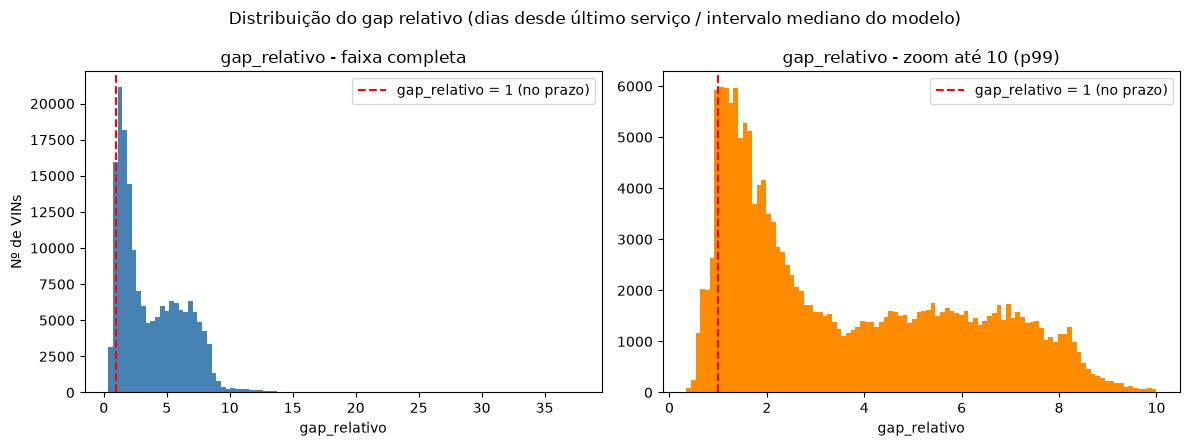

Gráfico salvo em: C:\Users\bruno\Desktop\challenge_next\ford-next\backend\notebooks\gap_relativo_histograma.png


In [4]:
fig, (ax_full, ax_zoom) = plt.subplots(1, 2, figsize=(12, 4.5))

ax_full.hist(gap, bins=100, color="steelblue")
ax_full.axvline(1, color="red", linestyle="--", label="gap_relativo = 1 (no prazo)")
ax_full.set_title("gap_relativo - faixa completa")
ax_full.set_xlabel("gap_relativo")
ax_full.set_ylabel("Nº de VINs")
ax_full.legend()

ax_zoom.hist(gap[gap <= 10], bins=100, color="darkorange")
ax_zoom.axvline(1, color="red", linestyle="--", label="gap_relativo = 1 (no prazo)")
ax_zoom.set_title("gap_relativo - zoom até 10 (p99)")
ax_zoom.set_xlabel("gap_relativo")
ax_zoom.legend()

fig.suptitle("Distribuição do gap relativo (dias desde último serviço / intervalo mediano do modelo)")
fig.tight_layout()
fig.savefig(OUTPUT_PNG, dpi=150)
plt.show()

print(f"Gráfico salvo em: {pathlib.Path(OUTPUT_PNG).resolve()}")